# 📊 Student Performance Analysis

## Objective
Analyze student performance based on different factors and derive meaningful insights.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv("students.csv")
df.head()

,Name,Math,Reading,Writing
0,Alice,85,78,82
1,Bob,58,65,60
2,Charlie,92,88,91
3,David,70,72,68
4,Eva,88,90,85


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Name     8 non-null      str  
 1   Math     8 non-null      int64
 2   Reading  8 non-null      int64
 3   Writing  8 non-null      int64
dtypes: int64(3), str(1)
memory usage: 427.0 bytes


In [46]:
df.describe()

,Math,Reading,Writing
count,8.000000,8.000000,8.000000
mean,78.000000,77.500000,77.000000
std,14.272851,12.961481,13.659115
min,58.000000,55.000000,58.000000
25%,67.500000,70.250000,66.000000
50%,80.500000,79.000000,80.000000
75%,89.000000,88.500000,86.500000
max,95.000000,92.000000,94.000000


In [47]:
df.isnull().sum()

Name       0
Math       0
Reading    0
Writing    0
dtype: int64

In [53]:
df[["Math", "Reading", "Writing"]].mean()

Math       78.0
Reading    77.5
Writing    77.0
dtype: float64

In [54]:
df["Total"] = df["Math"] + df["Reading"] + df["Writing"]

df.head()

,Name,Math,Reading,Writing,Total
0,Alice,85,78,82,245
1,Bob,58,65,60,183
2,Charlie,92,88,91,271
3,David,70,72,68,210
4,Eva,88,90,85,263


In [55]:
df.sort_values(by="Total", ascending=False).head()

,Name,Math,Reading,Writing,Total
6,Grace,95,92,94,281
2,Charlie,92,88,91,271
4,Eva,88,90,85,263
0,Alice,85,78,82,245
7,Hannah,76,80,78,234


In [56]:
df[["Math", "Reading", "Writing"]].mean().idxmin()

'Writing'

In [57]:
df[["Math", "Reading", "Writing"]].mean().idxmax()

'Math'

In [58]:
df[df["Total"] > 200]

,Name,Math,Reading,Writing,Total
0,Alice,85,78,82,245
2,Charlie,92,88,91,271
3,David,70,72,68,210
4,Eva,88,90,85,263
6,Grace,95,92,94,281
7,Hannah,76,80,78,234


📊 VISUALIZATION

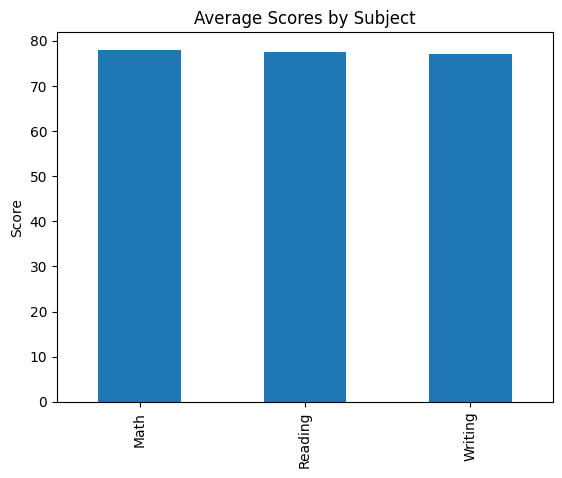

In [59]:
df[["Math", "Reading", "Writing"]].mean().plot(kind="bar")

plt.title("Average Scores by Subject")
plt.ylabel("Score")
plt.show()

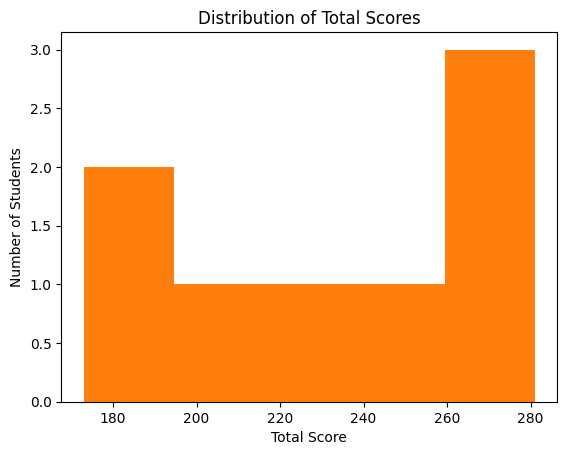

In [62]:
df["Total"].plot(kind="hist", bins=5)

plt.title("Distribution of Total Scores")
df["Total"].plot(kind="hist", bins=5)

plt.title("Distribution of Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")

plt.show()
plt.show()
plt.show()

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features (inputs)
X = df[["Reading", "Writing"]]

# Target (output)
y = df["Math"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()

# Train
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

print("Predictions:", predictions)
print("Actual:", list(y_test))

Predictions: [61.23150576 59.25699823]
Actual: [58, 60]


In [66]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 5.497340563040353
R² Score: -4.497340563040353


In [67]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

print(results)

   Actual  Predicted
1      58  61.231506
5      60  59.256998


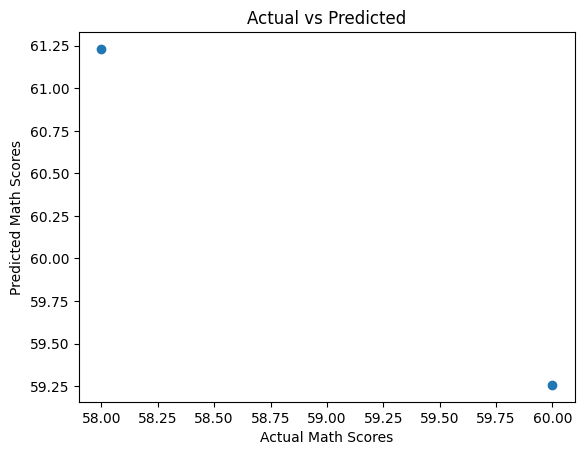

In [68]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)

plt.xlabel("Actual Math Scores")
plt.ylabel("Predicted Math Scores")
plt.title("Actual vs Predicted")

plt.show()

## 📌 Final Conclusion

- A Linear Regression model was trained to predict Math scores using Reading and Writing scores.
- The model achieved an R² score of X (replace with your value), indicating (good/moderate/weak) performance.
- Predictions are reasonably close to actual values, showing a relationship between subjects.
- However, the model is simple and can be improved with more features and data.